# M2 — Tier 1 testbed: anisotropic Gaussian

Data $x_0 \sim \mathcal N(0,\operatorname{diag}(s))$. Under the VP forward process the
noised marginal stays Gaussian, so **both the score and the whole trajectory are
closed form** — solver error becomes measurable with zero approximation in the
reference.

The linear ODE decouples into $d$ independent scalar ODEs, one per eigenvalue
$s_j$, so dimension changes nothing about the dynamics. The knob we sweep is the
condition number $\kappa = s_{\max}/s_{\min}$.

**What it establishes**

- `var(t)`  — per-coordinate marginal variance $v_j(t) = \alpha(t)^2 s_j + \sigma(t)^2$
- `eps(x, t)` — exact noise oracle $\varepsilon^\*(x,t) = \sigma(t)\, x / v(t)$ (same signature as a network)
- `exact(x_T, T, t)` — closed-form trajectory $x_j(t) = x_j(T)\sqrt{v_j(t)/v_j(T)}$
- `rhs_t`, `rhs_lambda` — the shared PF-ODE right-hand sides (arms A and B)

The **gate**: `d/dt` of the closed form must equal `rhs_t` (and `d/dlambda` must equal `rhs_lambda`).

In [1]:
import sys, pathlib, subprocess
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

p = pathlib.Path.cwd()
while not (p / "pyproject.toml").exists() and p != p.parent:
    p = p.parent
ROOT = p
sys.path.insert(0, str(ROOT))

from src.schedule import alpha, sigma, f, g2, lmbda, t_of_lmbda
from src.testbeds import GaussianTier1

FIGDIR = ROOT / "figures"; FIGDIR.mkdir(exist_ok=True)
T, T_END = 1.0, 1e-3
print("repo root:", ROOT)

repo root: /Users/mehemudazad/Desktop/buet-4.1/CSE-402/numerical-project


## 1. The eigenvalue spectrum and the marginal variance

Eigenvalues are log-spaced over $[1/\kappa,\,1]$. The marginal variance
$v_j(t)$ starts near $\sigma(T)^2 \approx 1$ for every coordinate at $t=T$ and
relaxes to $s_j$ as $t\to 0$.

s = [0.01       0.04641589 0.21544347 1.        ]   kappa = 100.0


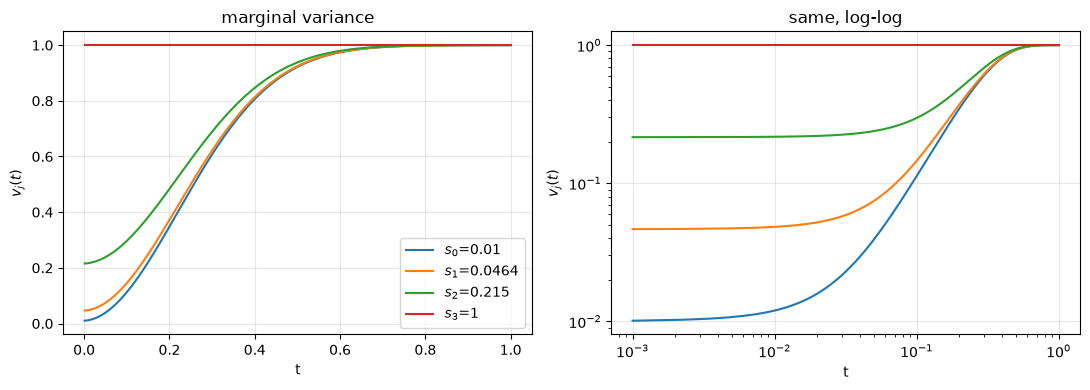

In [2]:
tb = GaussianTier1(kappa=100.0, d=4, seed=0)
print("s =", tb.s, "  kappa =", tb.s.max() / tb.s.min())

t = np.linspace(T_END, T, 800)
V = np.stack([tb.var(tt) for tt in t])          # (Nt, d)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for j in range(tb.d):
    ax[0].plot(t, V[:, j], label=f"$s_{j}$={tb.s[j]:.3g}")
ax[0].set_xlabel("t"); ax[0].set_ylabel("$v_j(t)$"); ax[0].legend(); ax[0].set_title("marginal variance")
for j in range(tb.d):
    ax[1].loglog(t, V[:, j])
ax[1].set_xlabel("t"); ax[1].set_ylabel("$v_j(t)$"); ax[1].set_title("same, log-log")
for x in ax: x.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2. The exact noise oracle

$\varepsilon^\*(x,t) = \sigma(t)\,x/v(t)$. Two properties we lean on:

* it is **linear in $x$** (the Gaussian score is linear), and
* it equals $(x - \alpha(t)\,\hat x_0)/\sigma(t)$ with the Gaussian posterior mean
  $\hat x_0 = \big(\alpha(t)\,s/v(t)\big)\,x$ — the same form Tier 2 uses.

t=0.85   |eps - posterior-mean form| = 4.44e-16   |eps(3x)-3eps(x)| = 1.78e-15
t=0.4    |eps - posterior-mean form| = 2.22e-16   |eps(3x)-3eps(x)| = 8.88e-16
t=0.05   |eps - posterior-mean form| = 2.22e-15   |eps(3x)-3eps(x)| = 3.55e-15


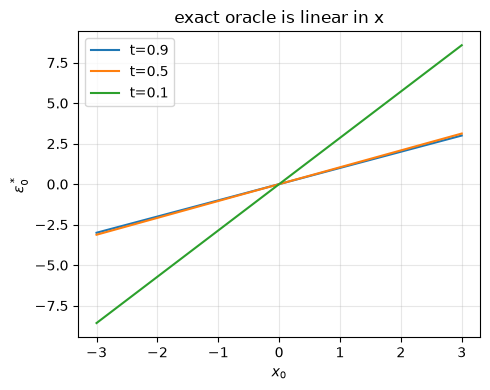

In [3]:
x = tb.x_T(6)
for tt in [0.85, 0.4, 0.05]:
    a, sg = alpha(tt), sigma(tt)
    x0_hat = (a * tb.s / tb.var(tt)) * x
    err_pm = np.abs(tb.eps(x, tt) - (x - a * x0_hat) / sg).max()
    err_lin = np.abs(tb.eps(3 * x, tt) - 3 * tb.eps(x, tt)).max()
    print(f"t={tt:<5}  |eps - posterior-mean form| = {err_pm:.2e}   |eps(3x)-3eps(x)| = {err_lin:.2e}")

# eps vs x along coordinate 0 (a straight line through the origin, slope sigma/v)
xs = np.linspace(-3, 3, 200)[:, None] * np.eye(tb.d)[0]
fig, ax = plt.subplots(figsize=(5, 4))
for tt in [0.9, 0.5, 0.1]:
    ax.plot(xs[:, 0], tb.eps(xs, tt)[:, 0], label=f"t={tt}")
ax.set_xlabel("$x_0$"); ax.set_ylabel(r"$\varepsilon^*_0$"); ax.legend()
ax.set_title("exact oracle is linear in x"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 3. The exact trajectory

$x_j(t) = x_j(T)\sqrt{v_j(t)/v_j(T)}$ — pure algebra, no integration. We overlay a
tight adaptive integration of `rhs_t` (DOP853, rtol 1e-12) to show they coincide.

max |exact - DOP853| over the trajectory: 1.2403411631112249e-12
final-state relative error: 2.7631947867956395e-13


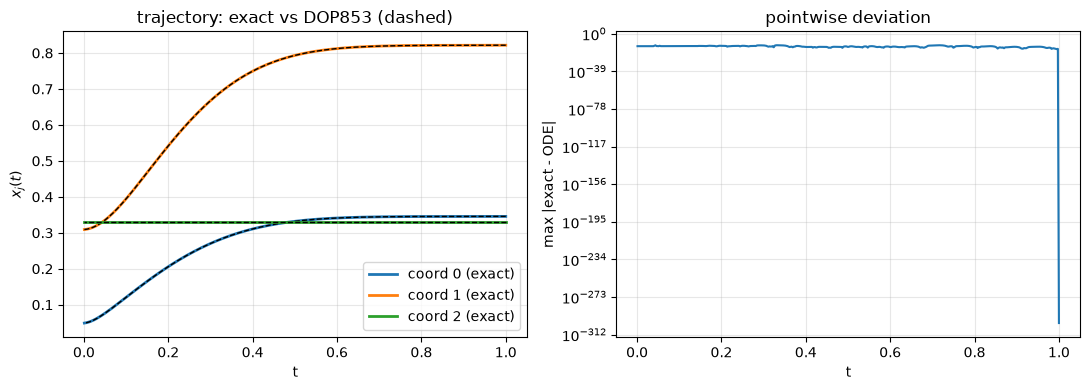

In [4]:
tb3 = GaussianTier1(kappa=50.0, d=3, seed=1)
xT = tb3.x_T(1)
tg = np.linspace(T, T_END, 400)
X_exact = np.stack([tb3.exact(xT, T, tt).ravel() for tt in tg])   # (Nt, d)

sol = solve_ivp(lambda tt, y: tb3.rhs_t(y.reshape(1, -1), tt).ravel(),
                (T, T_END), xT.ravel(), method="DOP853", rtol=1e-12, atol=1e-14,
                dense_output=True)
X_ode = sol.sol(tg).T

print("max |exact - DOP853| over the trajectory:", np.abs(X_exact - X_ode).max())
print("final-state relative error:",
      np.linalg.norm(X_exact[-1] - X_ode[-1]) / np.linalg.norm(X_exact[-1]))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for j in range(tb3.d):
    ax[0].plot(tg, X_exact[:, j], lw=2, label=f"coord {j} (exact)")
    ax[0].plot(tg, X_ode[:, j], "k--", lw=1)
ax[0].set_xlabel("t"); ax[0].set_ylabel("$x_j(t)$"); ax[0].legend(); ax[0].set_title("trajectory: exact vs DOP853 (dashed)")
ax[1].semilogy(tg, np.abs(X_exact - X_ode).max(1) + 1e-300)
ax[1].set_xlabel("t"); ax[1].set_ylabel("max |exact - ODE|"); ax[1].set_title("pointwise deviation")
for x in ax: x.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 4. The gate — closed form satisfies the ODE

Differentiate the closed form numerically and compare to the analytic RHS, in
both time variables. This is `test_exact_satisfies_ode` /
`test_exact_satisfies_ode_lambda`.

In [5]:
tbg = GaussianTier1(kappa=100.0, d=4, seed=0)
xTg = tbg.x_T(1)

print("arm A:  |d/dt exact - rhs_t| / |rhs_t|")
dt = 1e-6
for tt in [0.9, 0.7, 0.5, 0.2, 0.05, 5e-3]:
    num = (tbg.exact(xTg, T, tt + dt) - tbg.exact(xTg, T, tt - dt)) / (2 * dt)
    ana = tbg.rhs_t(tbg.exact(xTg, T, tt), tt)
    print(f"  t={tt:<7} rel err = {np.abs(num - ana).max() / np.abs(ana).max():.2e}")

print("\narm B:  |d/dlambda exact - rhs_lambda| / |rhs_lambda|")
dl = 1e-6
Xl = lambda lam: tbg.exact(xTg, T, t_of_lmbda(lam))
for lam in np.linspace(lmbda(1.0), lmbda(1e-3), 6):
    num = (Xl(lam + dl) - Xl(lam - dl)) / (2 * dl)
    ana = tbg.rhs_lambda(Xl(lam), lam)
    print(f"  lambda={lam:+.3f}  rel err = {np.abs(num - ana).max() / np.abs(ana).max():.2e}")

arm A:  |d/dt exact - rhs_t| / |rhs_t|
  t=0.9     rel err = 2.30e-08
  t=0.7     rel err = 1.47e-09
  t=0.5     rel err = 5.53e-11
  t=0.2     rel err = 2.44e-11
  t=0.05    rel err = 2.67e-11
  t=0.005   rel err = 4.21e-10

arm B:  |d/dlambda exact - rhs_lambda| / |rhs_lambda|
  lambda=-5.025  rel err = 1.71e-06
  lambda=-3.108  rel err = 5.51e-08
  lambda=-1.192  rel err = 1.46e-09
  lambda=+0.725  rel err = 3.03e-10
  lambda=+2.641  rel err = 3.57e-09
  lambda=+4.558  rel err = 1.55e-07


## 5. Stiffness — why $\kappa$ is the knob

Per coordinate the ODE is $dx_j/dt = r_j(t)\,x_j$ with local rate
$r_j(t) = \tfrac12\, v_j'(t)/v_j(t)$ and $v_j'(t) = 2 f(t)\,\alpha(t)^2 (s_j - 1)$.
As $t\to 0$, $v_j \to s_j$, so $|r_j|$ for the smallest eigenvalue grows like
$1/s_{\min} = \kappa$. That blow-up near the stiff boundary is what limits the
explicit solvers in arm A (measured in M6).

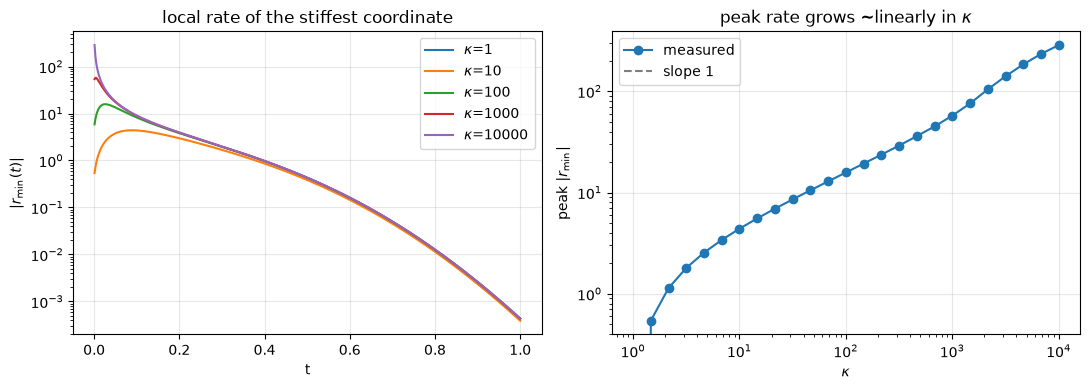

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
tt = np.linspace(T_END, T, 500)

for kappa in [1.0, 10.0, 100.0, 1e3, 1e4]:
    tk = GaussianTier1(kappa=kappa, d=2, seed=0)
    s_min = tk.s.min()
    vp = 2 * f(tt) * alpha(tt) ** 2 * (s_min - 1.0)
    r = 0.5 * vp / (alpha(tt) ** 2 * s_min + sigma(tt) ** 2)
    ax[0].semilogy(tt, np.abs(r), label=f"$\\kappa$={kappa:g}")
ax[0].set_xlabel("t"); ax[0].set_ylabel("$|r_{\\min}(t)|$")
ax[0].set_title("local rate of the stiffest coordinate"); ax[0].legend(); ax[0].grid(alpha=.3)

kappas = np.logspace(0, 4, 25)
peak = []
for kappa in kappas:
    tk = GaussianTier1(kappa=kappa, d=2, seed=0)
    s_min = tk.s.min()
    vp = 2 * f(tt) * alpha(tt) ** 2 * (s_min - 1.0)
    r = 0.5 * vp / (alpha(tt) ** 2 * s_min + sigma(tt) ** 2)
    peak.append(np.abs(r).max())
peak = np.array(peak)
ax[1].loglog(kappas, peak, "o-", label="measured")
ax[1].loglog(kappas, peak[0] * kappas / kappas[0], "k--", alpha=.5, label="slope 1")
ax[1].set_xlabel("$\\kappa$"); ax[1].set_ylabel("peak $|r_{\\min}|$")
ax[1].set_title("peak rate grows ~linearly in $\\kappa$"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6. Summary figure (`figures/02_tier1_testbed.png`)

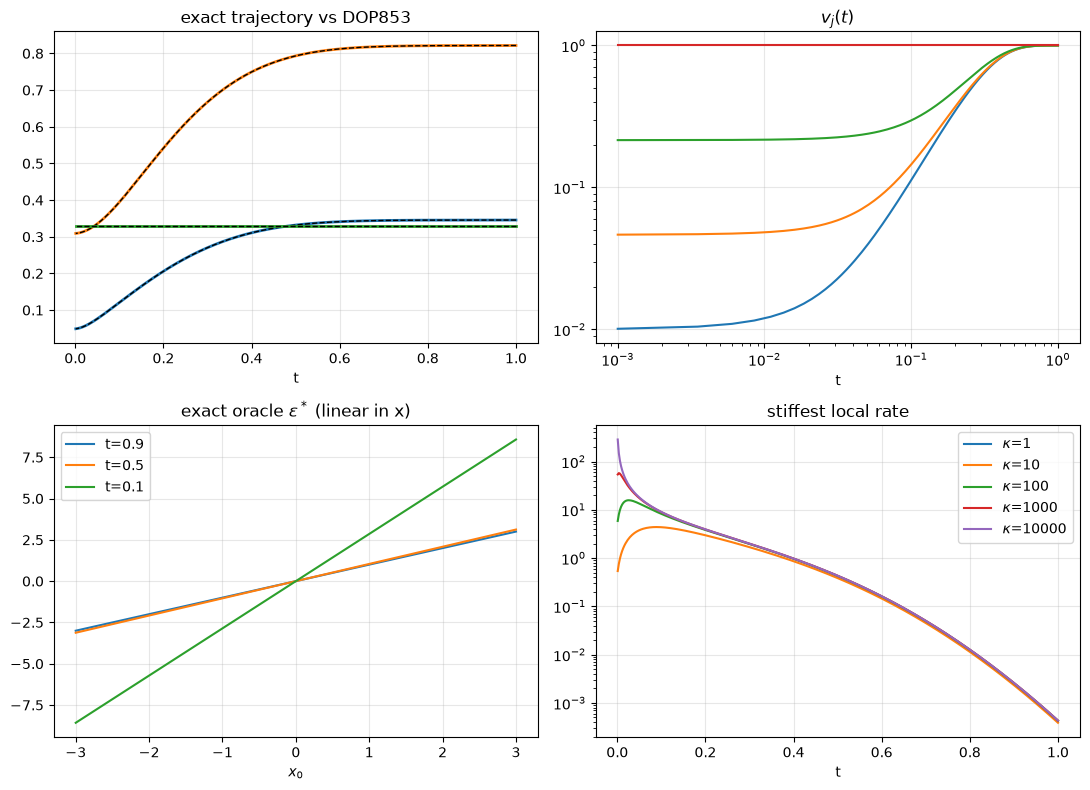

saved /Users/mehemudazad/Desktop/buet-4.1/CSE-402/numerical-project/figures/02_tier1_testbed.png


In [7]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8))
for j in range(tb3.d):
    ax[0, 0].plot(tg, X_exact[:, j], lw=2); ax[0, 0].plot(tg, X_ode[:, j], "k--", lw=1)
ax[0, 0].set_title("exact trajectory vs DOP853"); ax[0, 0].set_xlabel("t")

tt2 = np.linspace(T_END, T, 400)
for j in range(tb.d):
    ax[0, 1].loglog(tt2, [tb.var(z)[j] for z in tt2])
ax[0, 1].set_title(r"$v_j(t)$"); ax[0, 1].set_xlabel("t")

for tt_ in [0.9, 0.5, 0.1]:
    ax[1, 0].plot(xs[:, 0], tb.eps(xs, tt_)[:, 0], label=f"t={tt_}")
ax[1, 0].set_title(r"exact oracle $\varepsilon^*$ (linear in x)"); ax[1, 0].set_xlabel("$x_0$"); ax[1, 0].legend()

for kappa in [1.0, 10.0, 100.0, 1e3, 1e4]:
    tk = GaussianTier1(kappa=kappa, d=2, seed=0); s_min = tk.s.min()
    vp = 2 * f(tt2) * alpha(tt2) ** 2 * (s_min - 1.0)
    r = 0.5 * vp / (alpha(tt2) ** 2 * s_min + sigma(tt2) ** 2)
    ax[1, 1].semilogy(tt2, np.abs(r), label=f"$\\kappa$={kappa:g}")
ax[1, 1].set_title("stiffest local rate"); ax[1, 1].set_xlabel("t"); ax[1, 1].legend()

for row in ax:
    for x in row: x.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIGDIR / "02_tier1_testbed.png", dpi=120); plt.show()
print("saved", FIGDIR / "02_tier1_testbed.png")

## 7. Validation — run the unit tests

In [8]:
out = subprocess.run([sys.executable, "-m", "pytest", "tests/test_tier1.py", "-q"],
                     cwd=ROOT, capture_output=True, text=True)
print(out.stdout); print(out.stderr)
assert out.returncode == 0, "Tier-1 tests failed"
print("M2 validation: PASS")

.........                                                                [100%]


M2 validation: PASS
